# Questão 1 - EDA
### Cenário

Antes de qualquer análise, modelagem ou tomada de decisão, é fundamental entender o que
existe nos dados. O Sr. Almir quer uma resposta simples: "Posso confiar nesses dados para tomar
decisões?"

Sua missão é realizar uma análise exploratória inicial do dataset vendas_2023_2024.csv e
responder perguntas básicas, porém críticas, sobre volume, distribuição e qualidade dos dados

#### Premissas obrigatórias

- Utilize apenas o dataset vendas_2023_2024.csv
- Não faça limpeza nem tratamento dos dados
- Apenas observe, agregue e descreva

### Tarefas:

> Parte 1 - Visão geral do dataset

Informe:

* Quantidade total de linhas
* Quantidade total de colunas
* Intervalo de datas analisado (data mínima e máxima)


> Parte 2 - Análise de valores numéricos

Para a coluna "total", calcule:

* Valor mínimo
* Valor máximo
* Valor médio

> Parte 3 - Interpretação

Responda de forma resumida:
Com base na análise exploratória realizada, escreva um breve diagnóstico sobre a confiabilidade
do dataset vendas_2023_2024.csv para análises futuras.
Comente sobre:

- possíveis outliers em "total",
- qualidade dos dados (valores nulos ou inconsistentes).
- e se você considera que o dataset está pronto para análises ou se exigiria tratamento
prévio.

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
path_vendas = '../datasets/vendas_2023_2024.csv'

df_vendas = pd.read_csv(path_vendas)

print(f'Número de linhas: {df_vendas.shape[0]}\nNúmero de colunas: {df_vendas.shape[1]}')
df_vendas.head(10)

Número de linhas: 9895
Número de colunas: 6


,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,15-09-2024
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
5,6,36,52,3,39056.40,2023-09-26
6,8,27,25,3,34560.05,2024-02-28
7,9,37,26,7,114932.90,07-11-2023
8,10,31,143,3,12643.55,2024-08-25
9,11,39,128,5,23254.00,2023-05-07


In [54]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          9895 non-null   int64  
 1   id_client   9895 non-null   int64  
 2   id_product  9895 non-null   int64  
 3   qtd         9895 non-null   int64  
 4   total       9895 non-null   float64
 5   sale_date   9895 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 464.0+ KB


In [55]:
df_vendas.describe()

,id,id_client,id_product,qtd,total
count,9895.000000,9895.000000,9895.000000,9895.000000,9.895000e+03
mean,5000.755533,24.874583,75.255786,8.015260,2.637978e+05
std,2887.000000,14.177715,43.533397,4.301723,3.900072e+05
min,0.000000,1.000000,1.000000,1.000000,2.945000e+02
25%,2501.500000,13.000000,37.000000,4.000000,2.313820e+04
50%,4999.000000,25.000000,74.000000,8.000000,8.222500e+04
75%,7505.500000,37.000000,114.000000,12.000000,3.390945e+05
max,9999.000000,49.000000,150.000000,15.000000,2.222973e+06


# 1. Visão Geral do Dataset

In [56]:
print("-"*80)
print("                           Informações do Dataset")
print("-"*80)
print(f"Qts de Linhas   : {df_vendas.shape[0]}") 
print(f"Qts de Colunas  : {df_vendas.shape[1]}")
print(f"Colunas         : {df_vendas.columns.tolist()}\n")
print(f"Data Mínima : {df_vendas['sale_date'].min()}")
print(f"Data Máxima : {df_vendas['sale_date'].max()}")
print("-"*80)

--------------------------------------------------------------------------------
                           Informações do Dataset
--------------------------------------------------------------------------------
Qts de Linhas   : 9895
Qts de Colunas  : 6
Colunas         : ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date']

Data Mínima : 01-01-2023
Data Máxima : 31-12-2024
--------------------------------------------------------------------------------


In [57]:
# Tipos de dados e Análise de valores númericos
info_vendas = pd.DataFrame({
    "Tipo de Dado": df_vendas.dtypes,
    "Nulos": df_vendas.isnull().sum(),
    "Valores Únicos": df_vendas.nunique(),
    "Valor Mínimo": df_vendas.select_dtypes(include='number').min(),
    "Valor Máximo": df_vendas.select_dtypes(include='number').max(),
    "Valor Médio": df_vendas.select_dtypes(include='number').mean(),
    "Duplicados": df_vendas.duplicated().sum()
})
info_vendas

,Tipo de Dado,Nulos,Valores Únicos,Valor Mínimo,Valor Máximo,Valor Médio,Duplicados
id,int64,0,9895,0.0,9999.0,5000.755533,0
id_client,int64,0,49,1.0,49.0,24.874583,0
id_product,int64,0,150,1.0,150.0,75.255786,0
qtd,int64,0,15,1.0,15.0,8.015260,0
sale_date,object,0,1446,NaN,NaN,NaN,0
total,float64,0,3980,294.5,2222973.0,263797.828267,0


In [58]:
# Primeiras e últimas linhas do dataset
pd.concat([df_vendas.head(5), df_vendas.tail(5)])

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.00,2023-09-10
1,1,3,136,9,16873.90,15-09-2024
2,2,25,139,7,9475.30,2024-08-13
3,4,20,23,5,55893.00,2023-02-03
4,5,8,57,4,451403.90,2024-02-12
9890,9995,30,139,6,8549.00,11-03-2023
9891,9996,9,111,7,28497.15,17-09-2023
9892,9997,38,123,2,5276.30,20-06-2023
9893,9998,33,97,6,771409.50,23-10-2024
9894,9999,8,20,6,185001.00,15-06-2023


# 2. Análise de Valores Númericos

In [59]:
# Descrição estatística da coluna 'total'
desc = df_vendas["total"].describe()
print(f"Total - Descrição Estatística:\n{desc.round(2)}\n")

Total - Descrição Estatística:
count       9895.00
mean      263797.83
std       390007.18
min          294.50
25%        23138.20
50%        82225.00
75%       339094.50
max      2222973.00
Name: total, dtype: float64



In [60]:
print("-"*40)
print("              Estatísticas")
print("-"*40)
print(f"  Mínimo  : R$ {df_vendas['total'].min():>15,.2f}")
print(f"  Máximo  : R$ {df_vendas['total'].max():>15,.2f}")
print(f"  Média   : R$ {df_vendas['total'].mean():>15,.2f}\n")
print(f"  Mediana : R$ {df_vendas['total'].median():>15,.2f}")
print(f"  Desvio  : R$ {df_vendas['total'].std():>15,.2f}")
print(f"  IQR     : R$ {df_vendas['total'].quantile(.75) - df_vendas['total'].quantile(.25):>15,.2f}")

----------------------------------------
              Estatísticas
----------------------------------------
  Mínimo  : R$          294.50
  Máximo  : R$    2,222,973.00
  Média   : R$      263,797.83

  Mediana : R$       82,225.00
  Desvio  : R$      390,007.18
  IQR     : R$      315,956.30


### Inspeção da coluna `sale_date`
* Datas inconsistentes

In [61]:
# detecta formato sem converter
mask_iso = df_vendas["sale_date"].str.match(r"^\d{4}-\d{2}-\d{2}$")
mask_br  = df_vendas["sale_date"].str.match(r"^\d{2}-\d{2}-\d{4}$")

print(f"Formato YYYY-MM-DD : {mask_iso.sum():,} registros ({mask_iso.mean()*100:.1f}%)")
print(f"Formato DD-MM-YYYY : {mask_br.sum():,}  registros ({mask_br.mean()*100:.1f}%)")
print(f"Outros/inválidos   : {(~mask_iso & ~mask_br).sum()} registros")

Formato YYYY-MM-DD : 4,913 registros (49.7%)
Formato DD-MM-YYYY : 4,982  registros (50.3%)
Outros/inválidos   : 0 registros


In [62]:
# intervalo real (parseando os dois formatos para observação)
def try_parse(d):
    for fmt in ("%Y-%m-%d", "%d-%m-%Y"):
        try:
            return pd.to_datetime(d, format=fmt)
        except Exception:
            pass
    return pd.NaT

datas_parsed = df_vendas["sale_date"].apply(try_parse)

print(f"Data mínima parseada : {datas_parsed.min().date()}")
print(f"Data máxima parseada : {datas_parsed.max().date()}")
print(f"Datas não parseáveis : {datas_parsed.isna().sum()}")


Data mínima parseada : 2023-01-01
Data máxima parseada : 2024-12-31
Datas não parseáveis : 0


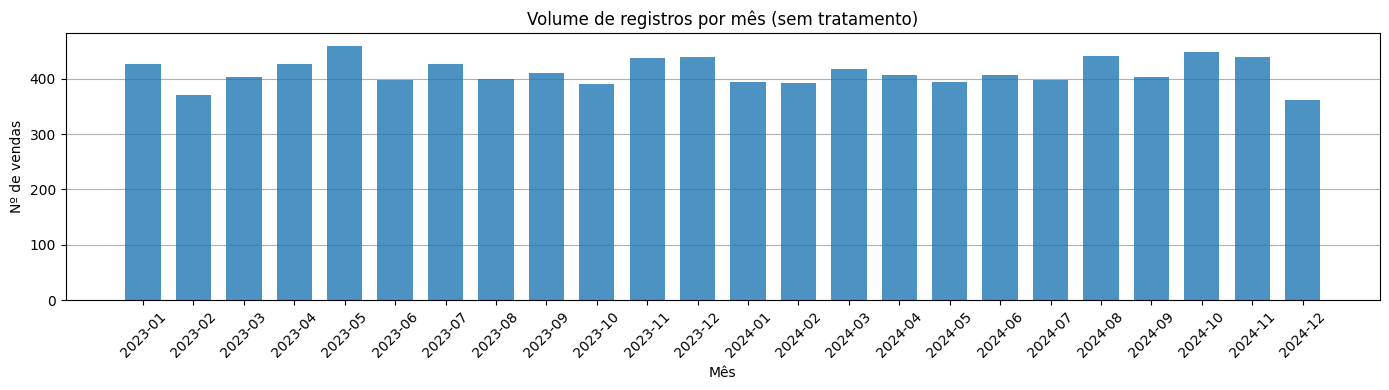

In [63]:
# distribuição de vendas por mês (só para visualização — sem tratar o df original)

vendas = df_vendas.copy()
vendas["date_parsed"] = datas_parsed
vendas["ym"] = vendas["date_parsed"].dt.to_period("M")

qtd_venda_mes = vendas.groupby("ym").size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(qtd_venda_mes.index.astype(str), qtd_venda_mes.values, alpha=0.8, width=0.7)
ax.set_title("Volume de registros por mês (sem tratamento)")
ax.set_xlabel("Mês")
ax.set_ylabel("Nº de vendas")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.grid(True); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [64]:
df_vendas.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,15-09-2024
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


# 3. Interpretação

In [24]:
q1 = df_vendas['total'].quantile(0.25)
q3 = df_vendas['total'].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr

outliers = df_vendas[df_vendas['total'] > limite_superior]

print(f"Q1: R$ {q1:,.2f}")
print(f"Q3: R$ {q3:,.2f}")
print(f"IQR: R$ {iqr:,.2f}\n")
print(f"Limite Superior: R$ {limite_superior:,.2f}\n")
print(f"Outliers identificados pelo método IQR: {len(outliers):,} registros ({len(outliers)/len(df_vendas)*100:.1f}%)")
print("-"*60, "\n")
print("Top 10 maiores vendas (possíveis outliers):")
print(df_vendas["total"].nlargest(10).reset_index(drop=True).apply(lambda x: f"R$ {x:,.2f}").to_string())


Q1: R$ 23,138.20
Q3: R$ 339,094.50
IQR: R$ 315,956.30

Limite Superior: R$ 813,028.95

Outliers identificados pelo método IQR: 1,018 registros (10.3%)
------------------------------------------------------------ 

Top 10 maiores vendas (possíveis outliers):
0    R$ 2,222,973.00
1    R$ 2,222,973.00
2    R$ 2,222,973.00
3    R$ 2,222,973.00
4    R$ 2,147,399.00
5    R$ 2,111,824.35
6    R$ 2,111,824.35
7    R$ 2,074,775.00
8    R$ 2,074,775.00
9    R$ 2,030,026.00


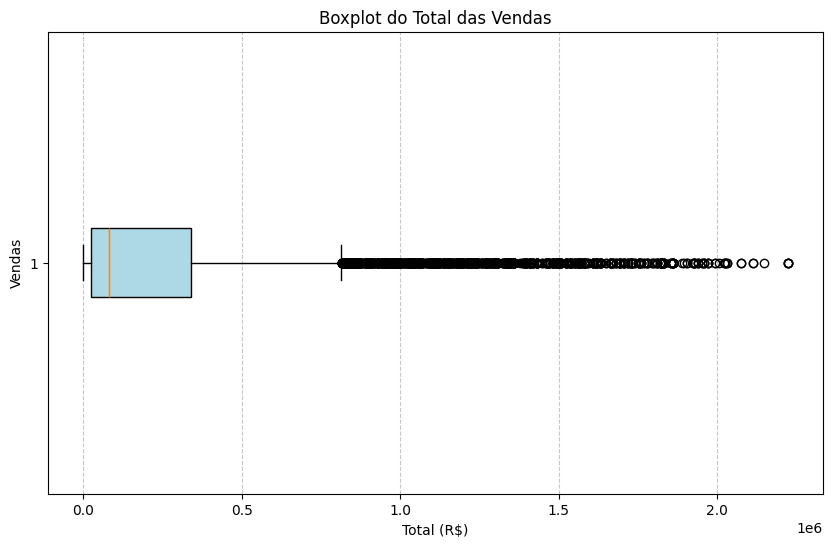

In [66]:
# Boxplot para identificar outliers
patch_artist=True 

plt.figure(figsize=(10, 6))
plt.boxplot(df_vendas['total'], vert=False, patch_artist=patch_artist, boxprops=dict(facecolor='lightblue'))
plt.title('Boxplot do Total das Vendas')
plt.xlabel('Total (R$)')
plt.ylabel('Vendas')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

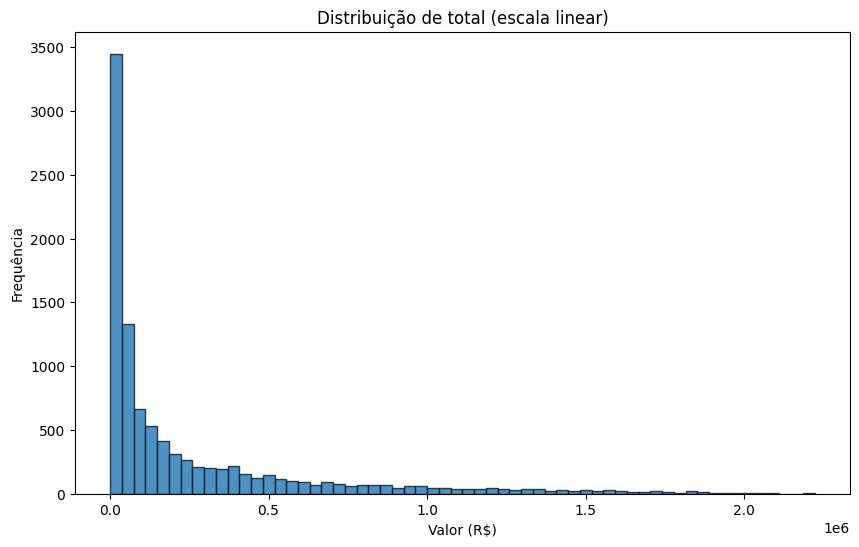

In [67]:
# histograma escala linear
plt.figure(figsize=(10, 6))
plt.hist(df_vendas["total"], bins=60, alpha=0.8, edgecolor="#091428")
plt.title("Distribuição de total (escala linear)")
plt.xlabel("Valor (R$)")
plt.ylabel("Frequência")
plt.show()


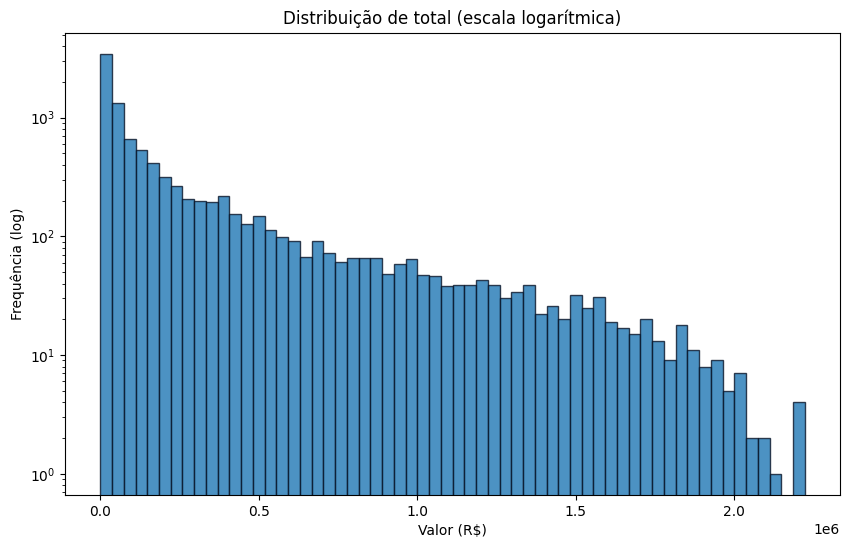

In [68]:
# histograma escala logarítmica
plt.figure(figsize=(10, 6))
plt.hist(df_vendas["total"], bins=60, alpha=0.8, edgecolor="#091428")
plt.yscale("log")   
plt.title("Distribuição de total (escala logarítmica)")
plt.xlabel("Valor (R$)")   
plt.ylabel("Frequência (log)")
plt.show()

In [69]:
# Vendas por cliente
vendas_cliente = df_vendas.groupby("id_client")["total"].sum().sort_values(ascending=False)
print("Top 10 clientes por valor total de vendas:")
print(vendas_cliente.head(10).apply(lambda x: f"R$ {x:,.2f}").to_string())


Top 10 clientes por valor total de vendas:
id_client
42    R$ 72,187,369.50
9     R$ 66,788,855.35
2     R$ 65,652,931.35
15    R$ 64,171,776.55
47    R$ 64,003,343.75
36    R$ 62,791,038.15
25    R$ 62,028,628.95
28    R$ 60,826,837.25
22    R$ 59,581,398.75
3     R$ 59,575,349.10


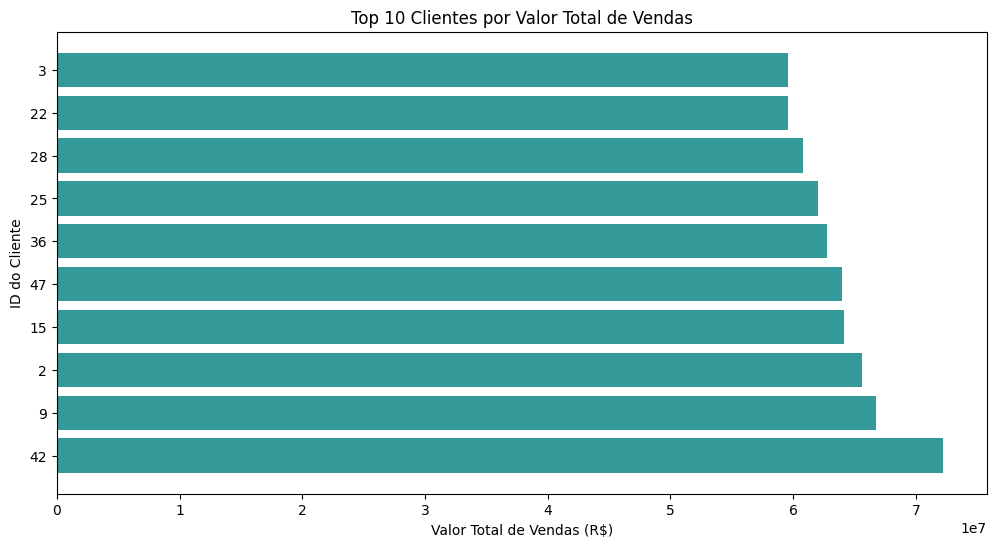

In [70]:
# Gráfico de barras para os 10 principais clientes
top_clientes = vendas_cliente.head(10)
plt.figure(figsize=(12, 6))
plt.barh(top_clientes.index.astype(str), top_clientes.values, color='teal', alpha=0.8)
plt.xlabel("Valor Total de Vendas (R$)")
plt.ylabel("ID do Cliente")
plt.title("Top 10 Clientes por Valor Total de Vendas")
plt.show()

In [71]:
# Vendas por produto
vendas_produto = df_vendas.groupby("id_product")["total"].sum().sort_values(ascending=False)
print("Top 10 produtos por valor total de vendas:")
print(vendas_produto.head(10).apply(lambda x: f"R$ {x:,.2f}").to_string())

Top 10 produtos por valor total de vendas:
id_product
76    R$ 83,539,339.40
71    R$ 81,567,066.65
73    R$ 69,554,254.80
63    R$ 68,817,185.90
80    R$ 67,332,086.05
91    R$ 66,829,268.70
54    R$ 65,859,716.10
81    R$ 64,195,127.60
72    R$ 63,057,815.65
55    R$ 61,224,375.00


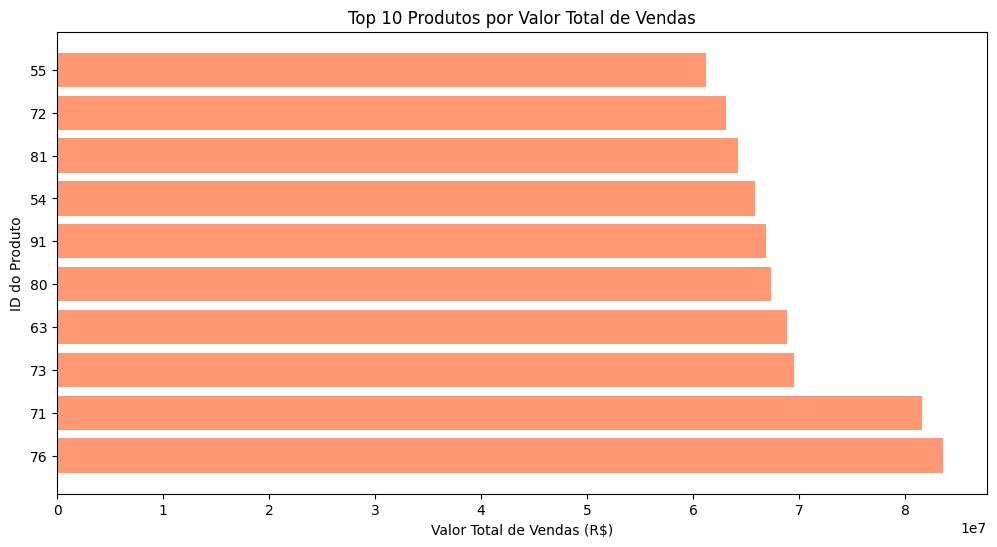

In [31]:
# Gráficos de barras para os 10 principais produtos
top_produtos = vendas_produto.head(10)
plt.figure(figsize=(12, 6))
plt.barh(top_produtos.index.astype(str), top_produtos.values, color='coral', alpha=0.8)
plt.xlabel("Valor Total de Vendas (R$)")
plt.ylabel("ID do Produto")
plt.title("Top 10 Produtos por Valor Total de Vendas")
plt.show()

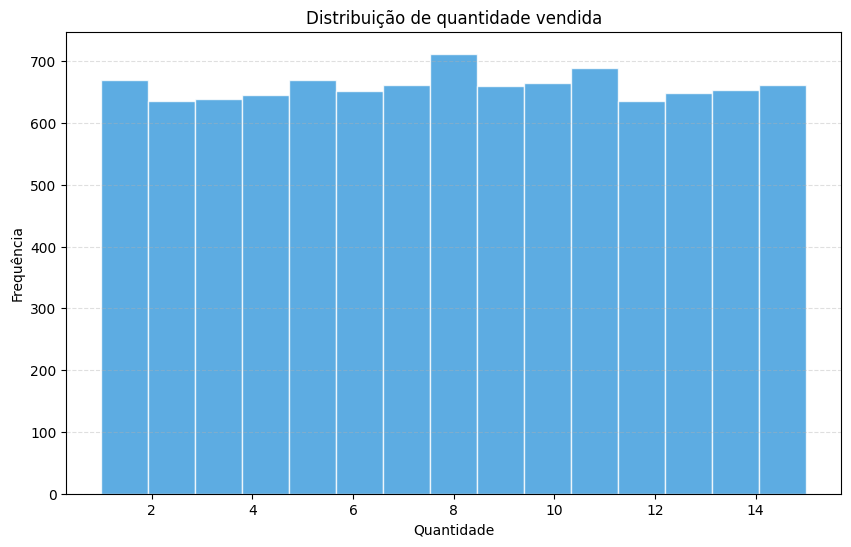

In [72]:
# Distribuição de qtd
plt.figure(figsize=(10, 6))
plt.hist(df_vendas["qtd"], bins=15, alpha=0.8, color='#3498db', edgecolor='white')
plt.title("Distribuição de quantidade vendida") 
plt.xlabel("Quantidade")
plt.ylabel("Frequência")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# **Diagnóstico de Confiabilidade**

##### Resposta ao Sr. Almir: "Posso confiar nesses dados para tomar decisões?"

##### **Sim, mas com ressalvas e após o tratamentos de dados prévio que deve ser obrigatório.**
---

### Outliers em total

A diferença entre média (R$263K) e mediana (R$82K) revela forte assimetria à direita.  
Pelo critério IQR, **1.018 registros (10,3%)** ultrapassam o limite de R$813K.  
O valor máximo de R$2.222.973 aparece repetido múltiplas vezes entre os maiores registros — pode ser legítimo (vendas volumosas de motores de alta potência) ou erro de entrada. Recomenda-se validar com a equipe comercial antes de usar `total` em modelos preditivos ou cálculo de ticket médio.

---

### Qualidade dos Dados 

O campo `sale_date` mistura **dois formatos distintos** no mesmo campo:
- `YYYY-MM-DD` → 4.913 registros (49,6%) — padrão internacional (e-commerce)
- `DD-MM-YYYY` → 4.982 registros (50,4%) — padrão brasileiro (loja física)

Qualquer análise temporal feita sem normalização das datas vai produzir resultados errados.  
Por exemplo, `07-11-2023` seria interpretado como **7 de novembro** ou **11 de julho** dependendo do parser.

**Pontos positivos:** zero valores nulos em todas as colunas, zero duplicatas de `id`, e os ranges de `id_client` (1–49) e `id_product` (1–150) são coerentes com os demais datasets.

---

### Veredicto
| Aspecto | Status |
|---|---|
| Valores nulos | Nenhum |
| Duplicatas | Nenhuma |
| Formato de datas | Dois formatos misturados — tratamento obrigatório |
| Outliers em `total` | 10,3% acima do limite IQR — investigar |
| Integridade de chaves | Ranges coerentes |
---

> **Recomendação:** normalizar `sale_date` para um único formato e investigar os valores extremos de `total` antes de qualquer análise ou modelagem.


In [ ]:
query = """
SELECT
    COUNT(*) AS total_linhas,
    COUNT(column_name) AS total_colunas,
    MIN(sale_date) AS data_minima,
    MAX(sale_date) AS data_maxima,
    COUNT(DISTINCT id_client) AS total_clientes,
    AVG(total) AS valor_medio
    MAX(qtd) AS qtd_maxima,
FROM vendas

SELECT COUNT(*) AS total_linhas,
FROM INFORMAÇÃO_SCHEMA.COLUMNS
WHERE table_name = 'vendas'
"""

In [74]:
# Converter Sale_date para datetime
# Attempt to parse dates with 'YYYY-MM-DD' format
parsed_dates_ymd = pd.to_datetime(df_vendas['sale_date'], format='%Y-%m-%d', errors='coerce')

# Attempt to parse dates with 'DD-MM-YYYY' format for remaining NaT values
parsed_dates_dmy = pd.to_datetime(df_vendas['sale_date'], format='%d-%m-%Y', errors='coerce')

# Combine the parsed dates: where ymd is NaT, use dmy
df_vendas['sale_date'] = parsed_dates_ymd.fillna(parsed_dates_dmy)

In [75]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 464.0 KB


In [76]:
df_vendas.head()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [78]:
# Salvando a base normalizada para uso nas próximas análises
df_vendas.to_csv('../datasets/vendas_normalizadas.csv', index=False)